# FT-Transformer: GPA-Change Regression

## Purpose

An attention-based architecture that converts tabular features into tokens and learns interactions between them through three Transformer blocks.

This standalone experiment uses exactly the same target, leakage-safe features, 80/20 split, and HGB reference metrics as `05_essential_gpa_change_regression.ipynb`.

## Evidence boundary

Results measure prediction within the supplied dataset. They do not establish that AI usage caused GPA changes.

## 1. Experiment contract

- Target: `Post_Semester_GPA - Pre_Semester_GPA`
- Development/test split: 80%/20%, random state 42
- Validation: shuffled five-fold cross-validation inside the development set
- Neural model selection: early stopping on each validation fold
- Test prediction: average predictions from all five fold models
- Primary metric: RMSE
- Secondary metrics: MAE, R², tolerance accuracy, residual bias, and training time
- Reference: HGB CV RMSE 0.1443 and test RMSE 0.1414

## 2. Setup, CUDA verification, and data loading

In [1]:
from pathlib import Path
import copy
import json
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
BATCH_SIZE = 512
MAX_EPOCHS = 80
EARLY_STOPPING_PATIENCE = 12
HGB_CV_RMSE = 0.1443
HGB_TEST_MAE = 0.1112
HGB_TEST_RMSE = 0.1414
HGB_TEST_R2 = 0.4185

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

def find_dataset():
    relative = Path("Datasets/Impact of AI on Students/ai_student_impact_dataset.csv")
    for start in [Path.cwd(), *Path.cwd().parents]:
        candidate = start / relative
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {relative}")

DATA_PATH = find_dataset()
df = pd.read_csv(DATA_PATH)
df["GPA_Change"] = df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]

print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("WARNING: CUDA is unavailable; training will use the CPU.")
print(f"Dataset: {len(df):,} rows, {df.shape[1] - 1} original columns plus GPA_Change")

PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 3080
CUDA: 12.8
Dataset: 50,000 rows, 16 original columns plus GPA_Change


## 3. Fold-local preprocessing and leakage controls

In [2]:
NUMERIC_FEATURES = [
    "Pre_Semester_GPA",
    "Traditional_Study_Hours",
    "Anxiety_Level_During_Exams",
    "Weekly_GenAI_Hours",
    "Tool_Diversity",
    "Perceived_AI_Dependency",
]

CATEGORICAL_FEATURES = [
    "Major_Category",
    "Year_of_Study",
    "Primary_Use_Case",
    "Prompt_Engineering_Skill",
    "Paid_Subscription",
    "Institutional_Policy",
]

FULL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
FORBIDDEN_FEATURES = {
    "Student_ID", "Post_Semester_GPA",
    "Skill_Retention_Score", "Burnout_Risk_Level",
}
assert not FORBIDDEN_FEATURES.intersection(FULL_FEATURES)

all_positions = np.arange(len(df))
development_positions, test_positions = train_test_split(
    all_positions,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

development_df = df.iloc[development_positions].reset_index(drop=True)
test_df = df.iloc[test_positions].reset_index(drop=True)

print(f"Development rows: {len(development_df):,}")
print(f"Untouched test rows: {len(test_df):,}")
display(pd.DataFrame({
    "Feature type": ["Numeric", "Categorical", "Target"],
    "Columns": [
        ", ".join(NUMERIC_FEATURES),
        ", ".join(CATEGORICAL_FEATURES),
        "GPA_Change",
    ],
}))

class FoldPreprocessor:
    # Fit numeric, categorical, and target transforms on one training fold only.

    def fit(self, frame):
        numeric = frame[NUMERIC_FEATURES].astype(float)
        self.numeric_mean = numeric.mean()
        self.numeric_std = numeric.std(ddof=0).replace(0, 1.0)

        self.category_maps = {}
        self.cat_cardinalities = []
        for column in CATEGORICAL_FEATURES:
            values = frame[column].astype(str)
            categories = sorted(values.unique().tolist())
            mapping = {value: index for index, value in enumerate(categories)}
            self.category_maps[column] = mapping
            self.cat_cardinalities.append(len(categories) + 1)

        target = frame["GPA_Change"].astype(float)
        self.target_mean = float(target.mean())
        self.target_std = float(target.std(ddof=0))
        if self.target_std == 0:
            self.target_std = 1.0
        return self

    def transform_features(self, frame):
        numeric = (
            (frame[NUMERIC_FEATURES].astype(float) - self.numeric_mean)
            / self.numeric_std
        ).to_numpy(dtype=np.float32)

        categorical_parts = []
        for column, cardinality in zip(
            CATEGORICAL_FEATURES, self.cat_cardinalities
        ):
            mapping = self.category_maps[column]
            unknown_code = cardinality - 1
            encoded = (
                frame[column].astype(str).map(mapping)
                .fillna(unknown_code)
                .to_numpy(dtype=np.int64)
            )
            categorical_parts.append(encoded)
        categorical = np.column_stack(categorical_parts).astype(np.int64)
        return numeric, categorical

    def transform_target(self, frame):
        target = frame["GPA_Change"].to_numpy(dtype=np.float32)
        return ((target - self.target_mean) / self.target_std).astype(np.float32)

    def inverse_target(self, values):
        return np.asarray(values) * self.target_std + self.target_mean

def make_loader(frame, preprocessor, shuffle, seed):
    numeric, categorical = preprocessor.transform_features(frame)
    target = preprocessor.transform_target(frame)
    dataset = TensorDataset(
        torch.from_numpy(numeric),
        torch.from_numpy(categorical),
        torch.from_numpy(target),
    )
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0,
        pin_memory=DEVICE.type == "cuda",
    )

Development rows: 40,000
Untouched test rows: 10,000


,Feature type,Columns
0,Numeric,"Pre_Semester_GPA, Traditional_Study_Hours, Anx..."
1,Categorical,"Major_Category, Year_of_Study, Primary_Use_Cas..."
2,Target,GPA_Change


## 4. Neural architecture

In [3]:
from rtdl_revisiting_models import FTTransformer

MODEL_NAME = "FT-Transformer"
ARCHITECTURE_NAME = "Three-block feature-tokenizer Transformer"
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-5

def make_model(cat_cardinalities):
    return FTTransformer(
        n_cont_features=len(NUMERIC_FEATURES),
        cat_cardinalities=cat_cardinalities,
        d_out=1,
        **FTTransformer.get_default_kwargs(n_blocks=3),
    )

parameter_count = sum(
    parameter.numel()
    for parameter in make_model([6, 6, 6, 4, 3, 4]).parameters()
)
print(f"Architecture: {ARCHITECTURE_NAME}")
print(f"Approximate parameter count: {parameter_count:,}")

Architecture: Three-block feature-tokenizer Transformer
Approximate parameter count: 900,865


## 5. Training and evaluation functions

In [4]:
def model_loss(output, target):
    if output.ndim == 3:
        expanded_target = target[:, None, None].expand_as(output)
        return nn.functional.smooth_l1_loss(output, expanded_target)
    return nn.functional.smooth_l1_loss(output.squeeze(-1), target)

def output_to_prediction(output):
    if output.ndim == 3:
        return output.mean(dim=1).squeeze(-1)
    return output.squeeze(-1)

@torch.no_grad()
def predict_standardized(model, loader):
    model.eval()
    predictions = []
    for numeric, categorical, _ in loader:
        numeric = numeric.to(DEVICE, non_blocking=True)
        categorical = categorical.to(DEVICE, non_blocking=True)
        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=AMP_ENABLED,
        ):
            output = model(numeric, categorical)
        predictions.append(output_to_prediction(output).float().cpu().numpy())
    return np.concatenate(predictions)

def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }

def train_one_fold(
    model,
    train_loader,
    validation_loader,
    preprocessor,
    learning_rate,
    weight_decay,
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    best_state = None
    best_validation_rmse = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    history = {"train_loss": [], "validation_rmse": []}
    start_time = time.perf_counter()

    validation_actual = []
    for _, _, target in validation_loader:
        validation_actual.append(target.numpy())
    validation_actual = preprocessor.inverse_target(
        np.concatenate(validation_actual)
    )

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        batch_losses = []
        for numeric, categorical, target in train_loader:
            numeric = numeric.to(DEVICE, non_blocking=True)
            categorical = categorical.to(DEVICE, non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=AMP_ENABLED,
            ):
                output = model(numeric, categorical)
                loss = model_loss(output, target)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            batch_losses.append(float(loss.detach().cpu()))

        validation_standardized = predict_standardized(model, validation_loader)
        validation_prediction = preprocessor.inverse_target(
            validation_standardized
        )
        validation_rmse = mean_squared_error(
            validation_actual, validation_prediction
        ) ** 0.5
        scheduler.step(validation_rmse)

        history["train_loss"].append(float(np.mean(batch_losses)))
        history["validation_rmse"].append(float(validation_rmse))

        if validation_rmse < best_validation_rmse - 1e-5:
            best_validation_rmse = float(validation_rmse)
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    training_seconds = time.perf_counter() - start_time
    return model, history, best_epoch, best_validation_rmse, training_seconds

## 6. Five-fold training and untouched-test ensemble

In [5]:
kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_rows = []
fold_test_predictions = []
fold_histories = []
experiment_start = time.perf_counter()

for fold_number, (train_fold_positions, validation_fold_positions) in enumerate(
    kfold.split(development_df),
    start=1,
):
    fold_seed = RANDOM_STATE + fold_number
    set_seed(fold_seed)

    fold_train = development_df.iloc[train_fold_positions].reset_index(drop=True)
    fold_validation = (
        development_df.iloc[validation_fold_positions].reset_index(drop=True)
    )
    preprocessor = FoldPreprocessor().fit(fold_train)

    train_loader = make_loader(
        fold_train, preprocessor, shuffle=True, seed=fold_seed
    )
    validation_loader = make_loader(
        fold_validation, preprocessor, shuffle=False, seed=fold_seed
    )
    test_loader = make_loader(
        test_df, preprocessor, shuffle=False, seed=fold_seed
    )

    model = make_model(preprocessor.cat_cardinalities).to(DEVICE)
    model, history, best_epoch, best_validation_rmse, training_seconds = (
        train_one_fold(
            model,
            train_loader,
            validation_loader,
            preprocessor,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )
    )

    validation_standardized = predict_standardized(model, validation_loader)
    validation_prediction = preprocessor.inverse_target(
        validation_standardized
    )
    validation_actual = fold_validation["GPA_Change"].to_numpy()
    validation_metrics = regression_metrics(
        validation_actual, validation_prediction
    )

    test_standardized = predict_standardized(model, test_loader)
    fold_test_predictions.append(
        preprocessor.inverse_target(test_standardized)
    )
    fold_histories.append(history)

    fold_rows.append({
        "Fold": fold_number,
        "Best epoch": best_epoch,
        "Validation MAE": validation_metrics["MAE"],
        "Validation RMSE": validation_metrics["RMSE"],
        "Validation R2": validation_metrics["R2"],
        "Training seconds": training_seconds,
    })
    print(
        f"Fold {fold_number}/{CV_FOLDS}: "
        f"RMSE={validation_metrics['RMSE']:.4f}, "
        f"R2={validation_metrics['R2']:.4f}, "
        f"epoch={best_epoch}, "
        f"time={training_seconds:.1f}s"
    )

    del model, train_loader, validation_loader, test_loader
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

fold_results = pd.DataFrame(fold_rows)
test_prediction = np.mean(np.vstack(fold_test_predictions), axis=0)
test_actual = test_df["GPA_Change"].to_numpy()
test_metrics = regression_metrics(test_actual, test_prediction)
total_training_seconds = time.perf_counter() - experiment_start

cv_summary = pd.Series({
    "CV MAE mean": fold_results["Validation MAE"].mean(),
    "CV MAE standard deviation": fold_results["Validation MAE"].std(ddof=1),
    "CV RMSE mean": fold_results["Validation RMSE"].mean(),
    "CV RMSE standard deviation": fold_results["Validation RMSE"].std(ddof=1),
    "CV R2 mean": fold_results["Validation R2"].mean(),
    "CV R2 standard deviation": fold_results["Validation R2"].std(ddof=1),
    "Total training seconds": total_training_seconds,
})

display(fold_results.style.format({
    "Validation MAE": "{:.4f}",
    "Validation RMSE": "{:.4f}",
    "Validation R2": "{:.4f}",
    "Training seconds": "{:.1f}",
}))
display(cv_summary.to_frame("Value").style.format("{:.4f}"))
display(pd.DataFrame([{
    "Model": MODEL_NAME,
    "Test MAE": test_metrics["MAE"],
    "Test RMSE": test_metrics["RMSE"],
    "Test R2": test_metrics["R2"],
}]).style.format({
    "Test MAE": "{:.4f}",
    "Test RMSE": "{:.4f}",
    "Test R2": "{:.4f}",
}))

Fold 1/5: RMSE=0.1445, R2=0.4185, epoch=13, time=39.2s


Fold 2/5: RMSE=0.1426, R2=0.4190, epoch=11, time=36.1s


Fold 3/5: RMSE=0.1440, R2=0.4140, epoch=13, time=39.9s


Fold 4/5: RMSE=0.1447, R2=0.3985, epoch=14, time=40.8s


Fold 5/5: RMSE=0.1441, R2=0.4037, epoch=20, time=50.7s


,Fold,Best epoch,Validation MAE,Validation RMSE,Validation R2,Training seconds
0,1,13,0.1134,0.1445,0.4185,39.2
1,2,11,0.1111,0.1426,0.4190,36.1
2,3,13,0.1130,0.1440,0.4140,39.9
3,4,14,0.1143,0.1447,0.3985,40.8
4,5,20,0.1120,0.1441,0.4037,50.7


,Value
CV MAE mean,0.1128
CV MAE standard deviation,0.0013
CV RMSE mean,0.1440
CV RMSE standard deviation,0.0008
CV R2 mean,0.4108
CV R2 standard deviation,0.0092
Total training seconds,209.9223


,Model,Test MAE,Test RMSE,Test R2
0,FT-Transformer,0.1109,0.1410,0.4218


## 7. Learning curves, residuals, and results analysis

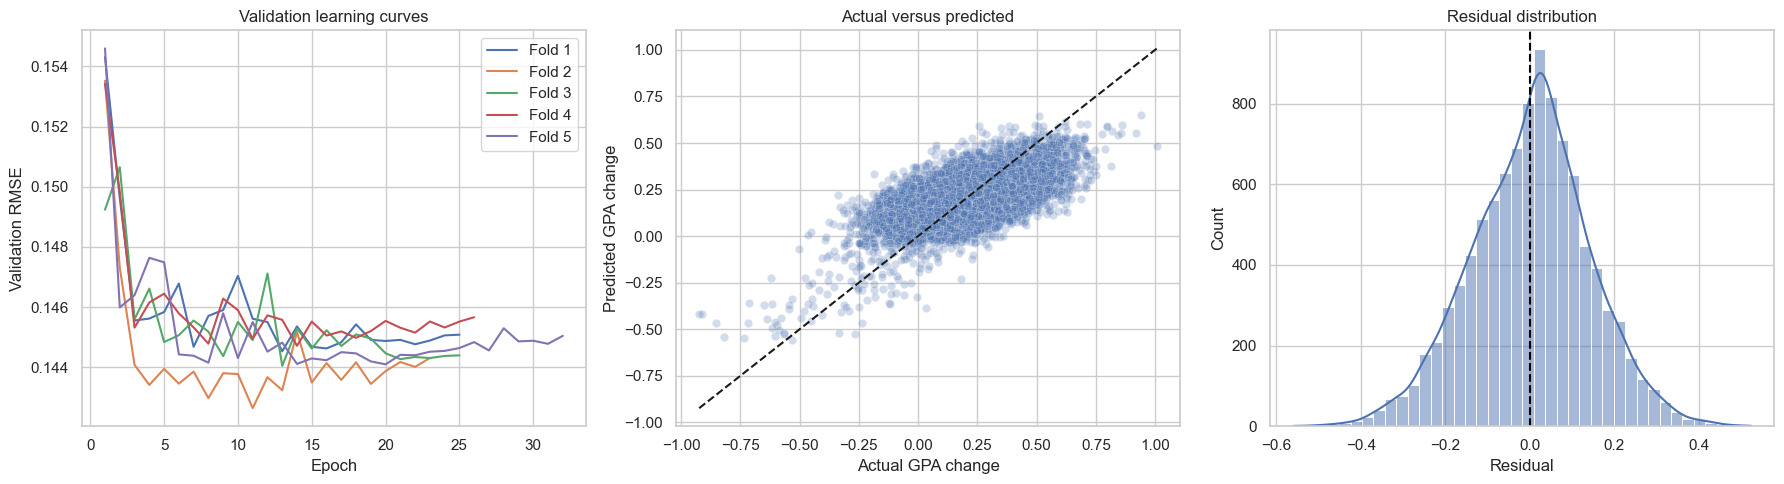

,Value
Mean residual,0.0020
Median absolute error,0.0916
Within 0.10 GPA points,0.5370
Within 0.20 GPA points,0.8424



### Cross-validation result

- Mean five-fold RMSE: **0.1440**
- Mean five-fold R²: **0.4108**
- HGB reference CV RMSE: **0.1443**
- Relative CV RMSE improvement: **+0.20%**

### Untouched-test result

- Test MAE: **0.1109**
- Test RMSE: **0.1410**
- Test R²: **0.4218**
- HGB reference test RMSE: **0.1414**
- Relative test RMSE improvement: **+0.31%**

### Error interpretation

- **53.7%** of predictions were within 0.10 GPA points.
- **84.2%** were within 0.20 GPA points.
- Mean residual was **+0.0020**.

### Decision

**FT-Transformer did not beat histogram gradient boosting by the required 1% cross-validation margin.**

The result is a predictive comparison only. It does not establish that AI usage caused GPA changes.


DL_RESULT_JSON={"model": "FT-Transformer", "architecture": "Three-block feature-tokenizer Transformer", "device": "cuda", "gpu": "NVIDIA GeForce RTX 3080", "folds": 5, "cv_mae_mean": 0.1127523123051986, "cv_mae_std": 0.0012599062279554539, "cv_rmse_mean": 0.14400741380757237, "cv_rmse_std": 0.0008140346664755243, "cv_r2_mean": 0.4107557866613313, "cv_r2_std": 0.009198587299563164, "test_mae": 0.1108812130977843, "test_rmse": 0.1409578398552132, "test_r2": 0.421828249934454, "within_0_10": 0.537, "within_0_20": 0.8424, "mean_residual": 0.0019629400060022484, "training_seconds": 209.9222590000063, "cv_improvement_pct_vs_hgb": 0.20276243411478911, "test_improvement_pct_vs_hgb": 0.312701658265057, "material_cv_win": false}


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for fold_number, history in enumerate(fold_histories, start=1):
    axes[0].plot(
        range(1, len(history["validation_rmse"]) + 1),
        history["validation_rmse"],
        label=f"Fold {fold_number}",
    )
axes[0].set(
    xlabel="Epoch",
    ylabel="Validation RMSE",
    title="Validation learning curves",
)
axes[0].legend()

sns.scatterplot(
    x=test_actual,
    y=test_prediction,
    alpha=0.25,
    ax=axes[1],
)
lower = min(float(test_actual.min()), float(test_prediction.min()))
upper = max(float(test_actual.max()), float(test_prediction.max()))
axes[1].plot([lower, upper], [lower, upper], "k--")
axes[1].set(
    xlabel="Actual GPA change",
    ylabel="Predicted GPA change",
    title="Actual versus predicted",
)

residuals = test_actual - test_prediction
sns.histplot(residuals, bins=40, kde=True, ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set(
    xlabel="Residual",
    title="Residual distribution",
)

fig.tight_layout()
plt.show()

absolute_errors = np.abs(residuals)
tolerance_results = pd.Series({
    "Mean residual": residuals.mean(),
    "Median absolute error": np.median(absolute_errors),
    "Within 0.10 GPA points": (absolute_errors <= 0.10).mean(),
    "Within 0.20 GPA points": (absolute_errors <= 0.20).mean(),
})
display(tolerance_results.to_frame("Value").style.format("{:.4f}"))

cv_rmse = float(cv_summary["CV RMSE mean"])
cv_r2 = float(cv_summary["CV R2 mean"])
test_rmse = float(test_metrics["RMSE"])
test_r2 = float(test_metrics["R2"])
cv_improvement_pct = (HGB_CV_RMSE - cv_rmse) / HGB_CV_RMSE * 100
test_improvement_pct = (HGB_TEST_RMSE - test_rmse) / HGB_TEST_RMSE * 100
material_cv_win = cv_rmse <= HGB_CV_RMSE * 0.99

if material_cv_win:
    verdict = (
        f"{MODEL_NAME} achieved a material cross-validation improvement "
        "over histogram gradient boosting."
    )
else:
    verdict = (
        f"{MODEL_NAME} did not beat histogram gradient boosting by the "
        "required 1% cross-validation margin."
    )

analysis_text = f'''
### Cross-validation result

- Mean five-fold RMSE: **{cv_rmse:.4f}**
- Mean five-fold R²: **{cv_r2:.4f}**
- HGB reference CV RMSE: **{HGB_CV_RMSE:.4f}**
- Relative CV RMSE improvement: **{cv_improvement_pct:+.2f}%**

### Untouched-test result

- Test MAE: **{test_metrics["MAE"]:.4f}**
- Test RMSE: **{test_rmse:.4f}**
- Test R²: **{test_r2:.4f}**
- HGB reference test RMSE: **{HGB_TEST_RMSE:.4f}**
- Relative test RMSE improvement: **{test_improvement_pct:+.2f}%**

### Error interpretation

- **{tolerance_results["Within 0.10 GPA points"]:.1%}** of predictions were within 0.10 GPA points.
- **{tolerance_results["Within 0.20 GPA points"]:.1%}** were within 0.20 GPA points.
- Mean residual was **{tolerance_results["Mean residual"]:+.4f}**.

### Decision

**{verdict}**

The result is a predictive comparison only. It does not establish that AI usage caused GPA changes.
'''
display(Markdown(analysis_text))

result_summary = {
    "model": MODEL_NAME,
    "architecture": ARCHITECTURE_NAME,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "folds": CV_FOLDS,
    "cv_mae_mean": float(cv_summary["CV MAE mean"]),
    "cv_mae_std": float(cv_summary["CV MAE standard deviation"]),
    "cv_rmse_mean": cv_rmse,
    "cv_rmse_std": float(cv_summary["CV RMSE standard deviation"]),
    "cv_r2_mean": cv_r2,
    "cv_r2_std": float(cv_summary["CV R2 standard deviation"]),
    "test_mae": float(test_metrics["MAE"]),
    "test_rmse": test_rmse,
    "test_r2": test_r2,
    "within_0_10": float(tolerance_results["Within 0.10 GPA points"]),
    "within_0_20": float(tolerance_results["Within 0.20 GPA points"]),
    "mean_residual": float(tolerance_results["Mean residual"]),
    "training_seconds": float(total_training_seconds),
    "cv_improvement_pct_vs_hgb": float(cv_improvement_pct),
    "test_improvement_pct_vs_hgb": float(test_improvement_pct),
    "material_cv_win": bool(material_cv_win),
}
print("DL_RESULT_JSON=" + json.dumps(result_summary))

## 8. Limitations and conclusion

- Neural results can vary with random initialization and hyperparameters.
- This experiment uses one literature-informed configuration and early stopping.
- The data has undocumented real-versus-synthetic provenance.
- Predictive feature relationships are not causal effects.
- The architecture should replace HGB only if its cross-validation improvement is stable and material.